In [1]:
import pandas as pd
import numpy as np
from umap import UMAP
import matplotlib.pyplot as plt
from scipy.stats import zscore
data_log2_Coimbra = pd.read_pickle('data_log2_Coimbra_threshold.pkl')
data_log2_LC = pd.read_pickle('data_log2_Lisbon_Coimbra_threshold.pkl')
data_log2_Lisbon = pd.read_pickle('data_log2_Lisbon_threshold.pkl')
import pickle
with open('prot_Coimbra.pkl', 'rb') as f:
    prot_Coimbra = pickle.load(f)
print(prot_Coimbra)
with open('prot_Lisbon.pkl', 'rb') as f:
    prot_Lisbon = pickle.load(f)
with open('prot_LC.pkl', 'rb') as f:
    prot_LC = pickle.load(f)
with open('list_groups_Coimbra.pkl', 'rb') as f:
    list_groups_Coimbra = pickle.load(f)

print(len(list_groups_Coimbra))


with open('list_groups_LC.pkl', 'rb') as f:
    list_groups_LC = pickle.load(f)

print(len(list_groups_LC))

with open('list_groups.pkl', 'rb') as f:
    list_groups_Lisbon = pickle.load(f)

print(len(list_groups_Lisbon))

Index(['Q14982', 'P02790', 'P07477', 'Q12805', 'P07339', 'Q13449', 'Q92876',
       'Q14118', 'P05090', 'P01023',
       ...
       'P06312', 'Q5SYB0', 'P01042', 'Q969P0', 'P05546', 'Q15582', 'Q13822',
       'Q14393', 'P35527', 'O00584'],
      dtype='object', length=115)
55
125
64


In [2]:
import numpy as np

# =========================
# --- COIMBRA ---
# =========================

groups_Coimbra = np.array(list_groups_Coimbra).astype(str)
groups_Coimbra = np.char.strip(groups_Coimbra)

mask_ad_Coimbra = groups_Coimbra == "MCI-AD"
mask_ctrl_Coimbra = groups_Coimbra == "MCI-CT"  

# NON sovrascrivo data_log2_Coimbra
data_AD_Coimbra = data_log2_Coimbra.loc[mask_ad_Coimbra]
data_CTRL_Coimbra = data_log2_Coimbra.loc[mask_ctrl_Coimbra]

proteins_Coimbra = prot_Coimbra.tolist()

proteins_present_Coimbra = data_log2_Coimbra.columns.intersection(proteins_Coimbra)

# mantengo naming coerente con pipeline
filtered_data_Coimbra = data_AD_Coimbra[proteins_present_Coimbra]
filtered_ctrl_Coimbra = data_CTRL_Coimbra[proteins_present_Coimbra]


# =========================
# --- LISBON ---
# =========================

groups_Lisbon = np.array(list_groups_Lisbon).astype(str)
groups_Lisbon = np.char.strip(groups_Lisbon)

mask_ad_Lisbon = groups_Lisbon == "MCI-AD"
mask_ctrl_Lisbon = groups_Lisbon == "MCI-CT"

data_AD_Lisbon = data_log2_Lisbon.loc[mask_ad_Lisbon]
data_CTRL_Lisbon = data_log2_Lisbon.loc[mask_ctrl_Lisbon]

proteins_Lisbon = prot_Lisbon.tolist()

proteins_present_Lisbon = data_log2_Lisbon.columns.intersection(proteins_Lisbon)

filtered_data_Lisbon = data_AD_Lisbon[proteins_present_Lisbon]
filtered_ctrl_Lisbon = data_CTRL_Lisbon[proteins_present_Lisbon]


# =========================
# --- LC (Merged) ---
# =========================

groups_LC = np.array(list_groups_LC).astype(str)
groups_LC = np.char.strip(groups_LC)

mask_ad_LC = groups_LC == "MCI-AD"
mask_ctrl_LC = groups_LC == "MCI-CT"

data_AD_LC = data_log2_LC.loc[mask_ad_LC]
data_CTRL_LC = data_log2_LC.loc[mask_ctrl_LC]

proteins_LC = prot_LC.tolist()

proteins_present_LC = data_log2_LC.columns.intersection(proteins_LC)

filtered_data_LC = data_AD_LC[proteins_present_LC]
filtered_ctrl_LC = data_CTRL_LC[proteins_present_LC]

In [3]:
proteins_present_Coimbra = proteins_present_Coimbra.tolist()
proteins_present_Lisbon = proteins_present_Lisbon.tolist()
proteins_present_LC = proteins_present_LC.tolist()

In [4]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()

# --- COIMBRA ---
X_scaled_Coimbra = scaler.fit_transform(filtered_data_Coimbra)
Coimbra_df = pd.DataFrame(
    X_scaled_Coimbra,
    index=filtered_data_Coimbra.index,
    columns=filtered_data_Coimbra.columns
)
# solo per NMF
Coimbra_nmf_df = pd.DataFrame(
    X_scaled_Coimbra - X_scaled_Coimbra.min(),
    index=filtered_data_Coimbra.index,
    columns=filtered_data_Coimbra.columns
)

# --- LISBON ---
X_scaled_Lisbon = scaler.fit_transform(filtered_data_Lisbon)
Lisbon_df = pd.DataFrame(
    X_scaled_Lisbon,
    index=filtered_data_Lisbon.index,
    columns=filtered_data_Lisbon.columns
)
# solo per NMF
Lisbon_nmf_df = pd.DataFrame(
    X_scaled_Lisbon - X_scaled_Lisbon.min(),
    index=filtered_data_Lisbon.index,
    columns=filtered_data_Lisbon.columns
)

# --- LC ---
X_scaled_LC = scaler.fit_transform(filtered_data_LC)
LC_df = pd.DataFrame(
    X_scaled_LC,
    index=filtered_data_LC.index,
    columns=filtered_data_LC.columns
)
# solo per NMF
LC_nmf_df = pd.DataFrame(
    X_scaled_LC - X_scaled_LC.min(),
    index=filtered_data_LC.index,
    columns=filtered_data_LC.columns
)

Grafico salvato come: dist_comparison_noshift_coimbra.png


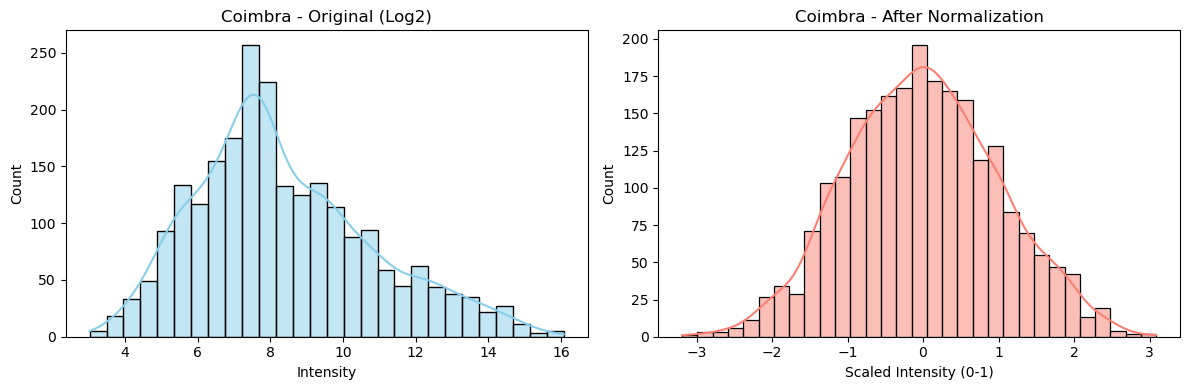

Grafico salvato come: dist_comparison_noshift_lisbon.png


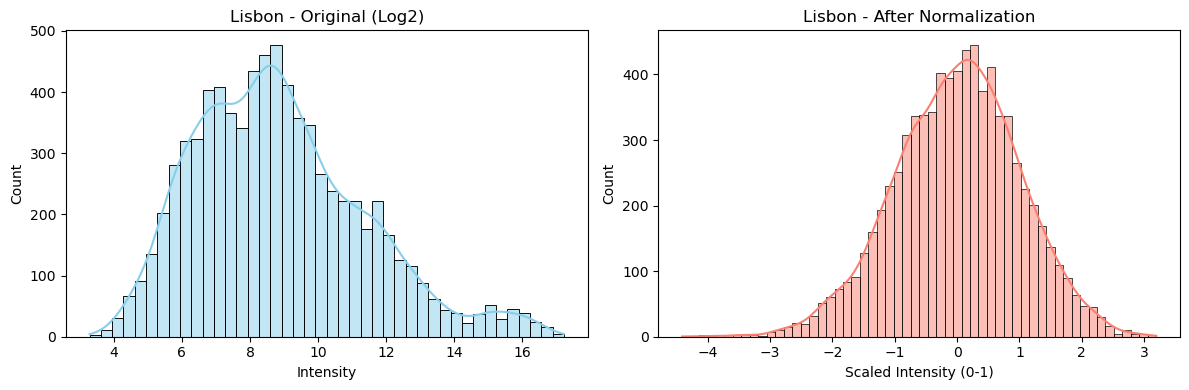

Grafico salvato come: dist_comparison_noshift_merged_lc.png


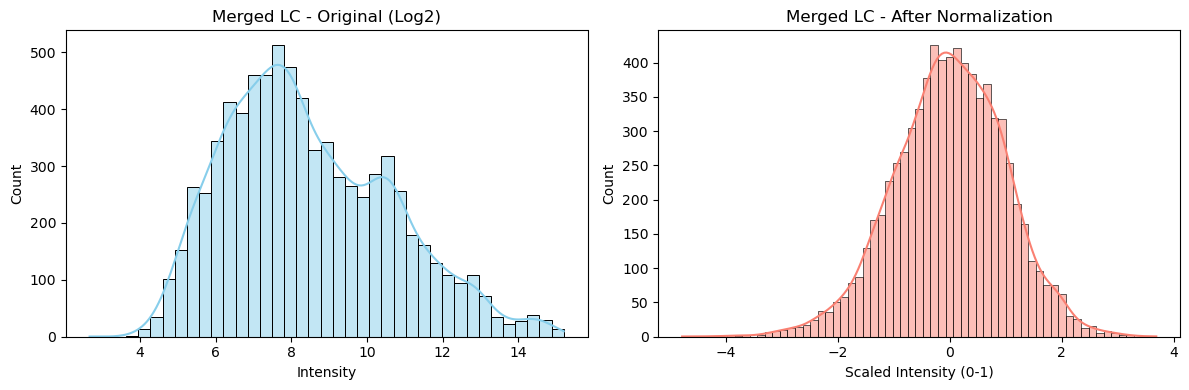

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_distribution_comparison(original, scaled, title):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    
    # Distribuzione Log2 originale
    sns.histplot(original.values.flatten(), kde=True, ax=ax[0], color='skyblue')
    ax[0].set_title(f'{title} - Original (Log2)')
    ax[0].set_xlabel('Intensity')
    
    # Distribuzione dopo MinMaxScaler
    sns.histplot(scaled.flatten(), kde=True, ax=ax[1], color='salmon')
    ax[1].set_title(f'{title} - After Normalization')
    ax[1].set_xlabel('Scaled Intensity (0-1)')
    
    plt.tight_layout()
    
    # Rendiamo il nome del file dinamico basandoci sul titolo
    # Sostituiamo eventuali spazi o caratteri speciali per sicurezza
    filename = f"dist_comparison_noshift_{title.replace(' ', '_').lower()}.png"
    print(f"Grafico salvato come: {filename}")
    plt.savefig(filename)
    plt.show()

# Esecuzione (i file verranno salvati separatamente)
plot_distribution_comparison(filtered_data_Coimbra, X_scaled_Coimbra, "Coimbra")
plot_distribution_comparison(filtered_data_Lisbon, X_scaled_Lisbon  , "Lisbon")
plot_distribution_comparison(filtered_data_LC, X_scaled_LC , "Merged LC")

In [6]:
patients_coimbra_k3 = ['103698', '108726', '106022', '100855', '106746', '104804', '105438', '102357', '107362']
patients_lisbon_k3 = ['LIS090', 'LIS001', 'LIS029', 'LIS005', 'LIS012', 'LIS002', 'LIS013', 'LIS043', 'LIS040', 'LIS047', 'LIS051', 'LIS049', 'LIS057', 'LIS068', 'LIS076', 'LIS004', 'LIS027', 'LIS052', 'LIS061', 'LIS069', 'LIS073', 'LIS081', 'LIS084', 'LIS085', 'LIS087', 'LIS088', 'LIS094', 'LIS096', 'LIS097', 'LIS102']
patients_lc_k3 = ['LIS090', 'LIS008', 'LIS011', 'LIS001', 'LIS031', 'LIS029', 'LIS005', 'LIS012', 'LIS018', 'LIS035', 'LIS033', 'LIS024', 'LIS002', 'LIS013', 'LIS043', 'LIS040', 'LIS047', 'LIS051', 'LIS049', 'LIS057', 'LIS064', 'LIS068', 'LIS076', 'LIS004', 'LIS027', 'LIS034', 'LIS052', 'LIS061', 'LIS069', 'LIS073', 'LIS081', 'LIS084', 'LIS085', 'LIS087', 'LIS088', 'LIS094', 'LIS096', 'LIS097', 'LIS102', 'LIS103', 'LIS117', '108726', '106022', '100112', '104726', '109089', '102357', '109522']



# Coimbra
patients_coimbra = ['103698', '107702', '104804', '100111', '102357']

# Lisbon
patients_lisbon = ['LIS090', 'LIS029', 'LIS005', 'LIS002', 'LIS043', 'LIS051', 'LIS049', 'LIS064', 'LIS076', 'LIS052', 'LIS073', 'LIS081', 'LIS084', 'LIS087', 'LIS094', 'LIS096', 'LIS097', 'LIS102', 'LIS117']

# LC
patients_lc = ['LIS090', 'LIS011', 'LIS001', 'LIS029', 'LIS005', 'LIS012', 'LIS018', 'LIS002', 'LIS043', 'LIS047', 'LIS051', 'LIS049', 'LIS076', 'LIS004', 'LIS034', 'LIS058', 'LIS073', 'LIS081', 'LIS084', 'LIS085', 'LIS087', 'LIS088', 'LIS094', 'LIS096', 'LIS097', 'LIS102', 'LIS117', '106022', '100596', '101960', '104726', '105438', '105080', '109901', '109089', '103176', '102357', '109522']

In [7]:
# ─────────────────────────
# REMOVE GREYZONE PATIENTS
# ─────────────────────────

Coimbra_nmf_df_clean = Coimbra_nmf_df.drop(
    index=patients_coimbra,
    errors="ignore"
)

Lisbon_nmf_df_clean = Lisbon_nmf_df.drop(
    index=patients_lisbon,
    errors="ignore"
)

LC_nmf_df_clean = LC_nmf_df.drop(
    index=patients_lc,
    errors="ignore"
)

# check
print("Coimbra:", Coimbra_nmf_df.shape, "->", Coimbra_nmf_df_clean.shape)
print("Lisbon:", Lisbon_nmf_df.shape, "->", Lisbon_nmf_df_clean.shape)
print("LC:", LC_nmf_df.shape, "->", LC_nmf_df_clean.shape)

Coimbra: (20, 115) -> (15, 115)
Lisbon: (42, 184) -> (23, 184)
LC: (67, 114) -> (29, 114)


In [39]:
from sklearn.decomposition import NMF
from scipy.optimize import linear_sum_assignment
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os


def plot_nmf_k2_membership_distribution(
    W_aligned,
    dataset_name,
    save=True,
    output_dir="."
):

    # ─────────────────────────
    # max membership
    # ─────────────────────────
    max_memberships = W_aligned.max(axis=2)

    # media across runs
    values = max_memberships.mean(axis=0)

    # ─────────────────────────
    # plot
    # ─────────────────────────
    plt.figure(figsize=(6, 4))

    plt.hist(
        values,
        bins=30,
        density=True
    )

    # threshold greyzone k=2
    plt.axvline(
        0.6,
        linestyle="--",
        color="red",
        label="Greyzone threshold"
    )

    plt.xlabel("Mean max membership (confidence)")
    plt.ylabel("Density")

    plt.title(
        f"{dataset_name} — NMF confidence distribution (k=2)"
    )

    plt.legend()

    plt.grid(
        True,
        linestyle='--',
        alpha=0.4
    )

    plt.tight_layout()

    # ─────────────────────────
    # save
    # ─────────────────────────
    if save:

        filename = (
            f"{dataset_name}_NMF_k2_membership_distribution.png"
        )

        filepath = os.path.join(output_dir, filename)

        plt.savefig(
            filepath,
            dpi=300
        )

    plt.show()


def nmf_k2_analysis(df, name, n_runs=50):

    X = df.values if hasattr(df, "values") else df
    k = 2

    W_list = []

    print(f"\n{'='*60}")
    print(f"{name} — NMF k=2 ({n_runs} runs)")
    print(f"{'='*60}")

    # ─────────────────────────
    # RUN MULTIPLE
    # ─────────────────────────
    for seed in range(n_runs):

        nmf = NMF(
            n_components=k,
            init='random',
            max_iter=10000,
            random_state=seed
        )

        W = nmf.fit_transform(X)

        # normalizzazione membership
        W = W / W.sum(axis=1, keepdims=True)

        W_list.append(W)

    W_list = np.array(W_list)

    # ─────────────────────────
    # ALIGNMENT COMPONENTS
    # ─────────────────────────
    ref = W_list[0]
    W_aligned = [ref]

    for W in W_list[1:]:

        cost = np.zeros((k, k))

        for i in range(k):
            for j in range(k):
                cost[i, j] = np.linalg.norm(ref[:, i] - W[:, j])

        _, col_ind = linear_sum_assignment(cost)

        W_aligned.append(W[:, col_ind])

    W_aligned = np.array(W_aligned)

    # ─────────────────────────
    # LABELS
    # ─────────────────────────
    all_labels = np.argmax(W_aligned, axis=2)

    # ─────────────────────────
    # COMPONENT STABILITY
    # ─────────────────────────
    print("\n--- NMF component stability ---")

    similarities = []

    for i in range(1, n_runs):

        W_i = W_aligned[i]

        sim_per_cluster = []

        for c in range(k):

            ref_vec = ref[:, c]
            vec = W_i[:, c]

            num = np.dot(ref_vec, vec)

            den = (
                np.linalg.norm(ref_vec)
                * np.linalg.norm(vec)
                + 1e-10
            )

            sim = num / den

            sim_per_cluster.append(sim)

        similarities.append(sim_per_cluster)

    similarities = np.array(similarities)

    for c in range(k):

        vals = similarities[:, c]

        print(f"\nCluster {c}:")
        print(f"  Cosine sim = {vals.mean():.3f} ± {vals.std():.3f}")
    # ─────────────────────────
    # CONSENSUS TOP FEATURES
    # ─────────────────────────
    
    print("\n=== CONSENSUS TOP FEATURES ===")
    
    top_n = 30
    
    # rifit modelli per salvare H
    models = []
    
    for seed in range(n_runs):
    
        nmf = NMF(
            n_components=k,
            init='random',
            max_iter=10000,
            random_state=seed
        )
    
        nmf.fit(X)
    
        models.append(nmf)
    
    # riferimento
    H_ref = models[0].components_
    
    # strutture consenso
    feature_frequency = {
        c: pd.Series(0, index=df.columns, dtype=float)
        for c in range(k)
    }
    
    feature_rank_sum = {
        c: pd.Series(0, index=df.columns, dtype=float)
        for c in range(k)
    }
    
    # ─────────────────────────
    # ALIGNMENT + CONSENSUS
    # ─────────────────────────
    for model in models:
    
        H_run = model.components_
    
        # Hungarian matching
        cost = np.zeros((k, k))
    
        for i in range(k):
            for j in range(k):
    
                cost[i, j] = np.linalg.norm(
                    H_ref[i] - H_run[j]
                )
    
        _, col_ind = linear_sum_assignment(cost)
    
        H_aligned = H_run[col_ind]
    
        # ranking feature
        for c in range(k):
    
            ranked_idx = np.argsort(
                H_aligned[c]
            )[::-1][:top_n]
    
            for rank, idx in enumerate(
                ranked_idx,
                start=1
            ):
    
                feat = df.columns[idx]
    
                feature_frequency[c][feat] += 1
                feature_rank_sum[c][feat] += rank
    
    # ─────────────────────────
    # PRINT RESULTS
    # ─────────────────────────
    for c in range(k):
    
        print(f"\n--- Cluster {c} ---")
    
        df_features = pd.DataFrame({
            "frequency": feature_frequency[c],
            "rank_sum": feature_rank_sum[c]
        })
    
        df_features = df_features[
            df_features["frequency"] > 0
        ]
    
        df_features["mean_rank"] = (
            df_features["rank_sum"]
            / df_features["frequency"]
        )
    
        df_features = df_features.sort_values(
            by=["frequency", "mean_rank"],
            ascending=[False, True]
        )
    
        df_top = df_features.head(30)
    
        for i, (feat, row) in enumerate(
            df_top.iterrows(),
            start=1
        ):
    
            print(
                f"{i:02d}. "
                f"{feat} | "
                f"freq={int(row['frequency'])}/{n_runs} | "
                f"mean_rank={row['mean_rank']:.2f}"
            )
    # ─────────────────────────
    # SAVE CONSENSUS FEATURES
    # ─────────────────────────
    
    consensus_features = {}
    
    for c in range(k):
    
        df_features = pd.DataFrame({
            "frequency": feature_frequency[c],
            "rank_sum": feature_rank_sum[c]
        })
    
        df_features = df_features[
            df_features["frequency"] > 0
        ]
    
        df_features["mean_rank"] = (
            df_features["rank_sum"]
            / df_features["frequency"]
        )
    
        df_features = df_features.sort_values(
            by=["frequency", "mean_rank"],
            ascending=[False, True]
        )
    
        df_top = df_features.head(30)
    
        # salva dataframe completo
        consensus_features[c] = df_top.copy()
    # ─────────────────────────
    # MEMBERSHIP STABILITY
    # ─────────────────────────
    print(f"\n--- NMF membership stability ---")

    max_memberships = W_aligned.max(axis=2)

    mean_conf = max_memberships.mean(axis=0)

    df_conf = pd.DataFrame({
        "mean_membership": mean_conf
    }, index=df.index)

    df_conf["category"] = pd.cut(
        df_conf["mean_membership"],
        bins=[0.5, 0.6, 0.7, 1.0],
        labels=[
            "greyzone (0.5-0.6)",
            "borderline (0.6-0.7)",
            "clear (>0.7)"
        ]
    )

    print("\nDistribution:")
    print(df_conf["category"].value_counts())

    nmf_grey_k2 = df_conf[
        df_conf["category"] == "greyzone (0.5-0.6)"
    ].index.tolist()

    print("\nNMF greyzone patients (k=2):")
    print(nmf_grey_k2)

    # ─────────────────────────
    # LC DATASET COMPOSITION
    # ─────────────────────────
    if name == "LC":

        print(f"\n--- LC cluster composition ---")

        def get_origin(p):
            return 1 if str(p).startswith("LIS") else 0

        origins = np.array([
            get_origin(p)
            for p in df.index
        ])

        comps_all = {c: [] for c in range(k)}

        for labels in all_labels:

            for c in range(k):

                mask = labels == c

                if mask.sum() > 0:

                    lisbon_frac = origins[mask].mean() * 100

                    comps_all[c].append(lisbon_frac)

        for c in range(k):

            vals = np.array(comps_all[c])

            print(f"\nCluster {c}:")

            print(
                f"  Lisbon  = "
                f"{vals.mean():.1f}% ± {vals.std():.1f}%"
            )

            print(
                f"  Coimbra = "
                f"{100 - vals.mean():.1f}% ± {vals.std():.1f}%"
            )

    return (
        all_labels,
        W_aligned,
        nmf_grey_k2,
        consensus_features
    )


Coimbra — NMF k=2 (50 runs)

--- NMF component stability ---

Cluster 0:
  Cosine sim = 0.997 ± 0.003

Cluster 1:
  Cosine sim = 0.999 ± 0.001

=== CONSENSUS TOP FEATURES ===

--- Cluster 0 ---
01. P04217 | freq=50/50 | mean_rank=1.00
02. P02765 | freq=50/50 | mean_rank=2.68
03. P02774 | freq=50/50 | mean_rank=3.50
04. P27169 | freq=50/50 | mean_rank=4.22
05. P51884 | freq=50/50 | mean_rank=4.50
06. P02647 | freq=50/50 | mean_rank=6.00
07. P02753 | freq=50/50 | mean_rank=7.02
08. P02790 | freq=50/50 | mean_rank=7.30
09. P02760 | freq=50/50 | mean_rank=8.80
10. P01042 | freq=50/50 | mean_rank=10.46
11. P25311 | freq=50/50 | mean_rank=10.80
12. P01009 | freq=50/50 | mean_rank=11.72
13. P08697 | freq=50/50 | mean_rank=13.36
14. P05156 | freq=50/50 | mean_rank=13.64
15. A0A075B6K5 | freq=50/50 | mean_rank=15.00
16. P02766 | freq=50/50 | mean_rank=16.42
17. P04196 | freq=50/50 | mean_rank=17.28
18. B9A064 | freq=50/50 | mean_rank=17.30
19. P0DOY2;P0DOY3 | freq=50/50 | mean_rank=19.40
20. P

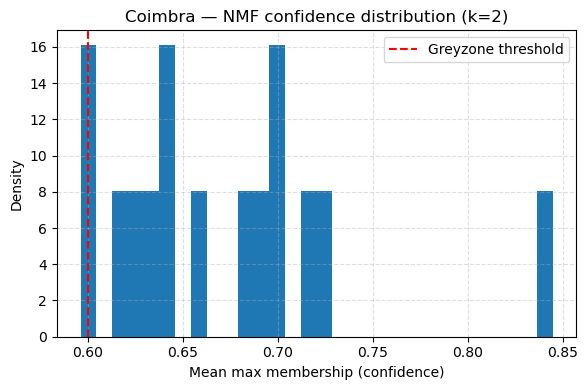

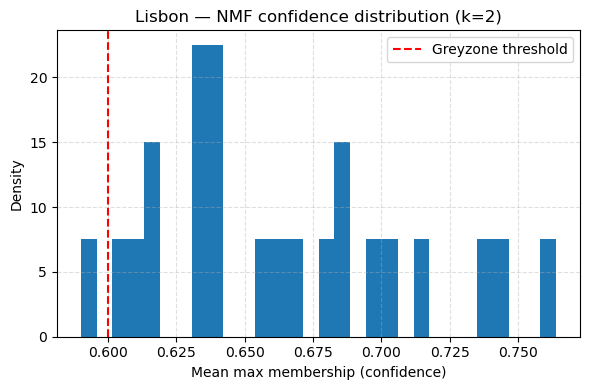

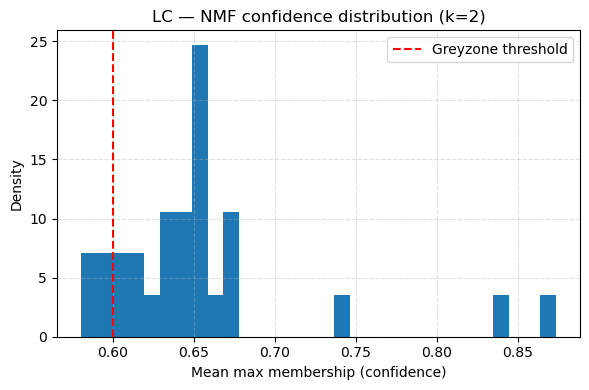

In [51]:
nmf_k2_results = {}

nmf_k2_results["Coimbra"] = nmf_k2_analysis(
    Coimbra_nmf_df_clean,
    "Coimbra"
)

nmf_k2_results["Lisbon"] = nmf_k2_analysis(
    Lisbon_nmf_df_clean,
    "Lisbon"
)

nmf_k2_results["LC"] = nmf_k2_analysis(
    LC_nmf_df_clean,
    "LC"
)
coimbra_features = nmf_k2_results["Coimbra"][3]

lisbon_features = nmf_k2_results["Lisbon"][3]

lc_features = nmf_k2_results["LC"][3]
# ─────────────────────────
# PLOTS
# ─────────────────────────

# Coimbra
plot_nmf_k2_membership_distribution(
    nmf_k2_results["Coimbra"][1],
    "Coimbra"
)

# Lisbon
plot_nmf_k2_membership_distribution(
    nmf_k2_results["Lisbon"][1],
    "Lisbon"
)

# LC
plot_nmf_k2_membership_distribution(
    nmf_k2_results["LC"][1],
    "LC"
)

In [67]:
coimbra_features = nmf_k2_results["Coimbra"][3]

lisbon_features = nmf_k2_results["Lisbon"][3]

lc_features = nmf_k2_results["LC"][3]


coimbra_cluster0 = coimbra_features[0].index.tolist()
coimbra_cluster1 = coimbra_features[1].index.tolist()


lisbon_cluster0 = lisbon_features[0].index.tolist()
lisbon_cluster1 = lisbon_features[1].index.tolist()


lc_cluster0 = lc_features[0].index.tolist()
lc_cluster1 = lc_features[1].index.tolist()

In [16]:
# ─────────────────────────
# KEEP ONLY GREYZONE PATIENTS
# ─────────────────────────

Coimbra_grey_df = Coimbra_nmf_df.loc[
    Coimbra_nmf_df.index.intersection(patients_coimbra)
]

Lisbon_grey_df = Lisbon_nmf_df.loc[
    Lisbon_nmf_df.index.intersection(patients_lisbon)
]

LC_grey_df = LC_nmf_df.loc[
    LC_nmf_df.index.intersection(patients_lc)
]


Coimbra_grey — NMF k=2 (50 runs)

--- NMF component stability ---

Cluster 0:
  Cosine sim = 0.996 ± 0.003

Cluster 1:
  Cosine sim = 0.997 ± 0.004

=== CONSENSUS TOP FEATURES ===

--- Cluster 0 ---
01. P18065 | freq=50/50 | mean_rank=1.00
02. P08294 | freq=50/50 | mean_rank=2.00
03. Q9NQ79 | freq=50/50 | mean_rank=3.00
04. P39060 | freq=50/50 | mean_rank=4.00
05. Q92876 | freq=50/50 | mean_rank=5.00
06. Q02246 | freq=50/50 | mean_rank=6.00
07. P36222 | freq=50/50 | mean_rank=7.00
08. Q12805 | freq=50/50 | mean_rank=8.00
09. Q16270 | freq=50/50 | mean_rank=9.30
10. P61916 | freq=50/50 | mean_rank=9.70
11. P16035 | freq=50/50 | mean_rank=11.00
12. P23142 | freq=50/50 | mean_rank=12.00
13. P07585 | freq=50/50 | mean_rank=13.00
14. Q13822 | freq=50/50 | mean_rank=14.00
15. Q15113 | freq=50/50 | mean_rank=15.00
16. P02452 | freq=50/50 | mean_rank=16.00
17. Q8NFZ8 | freq=50/50 | mean_rank=17.00
18. P41222 | freq=50/50 | mean_rank=18.42
19. P55058 | freq=50/50 | mean_rank=18.58
20. Q969P0 |

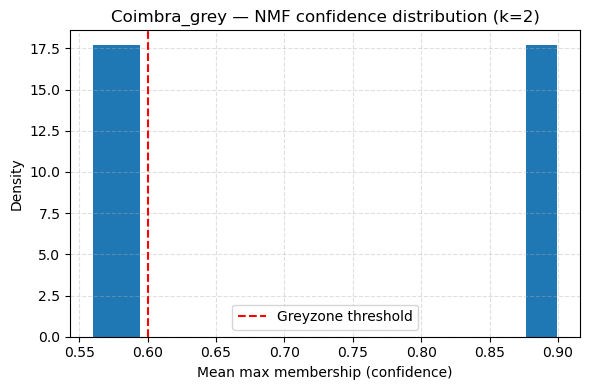

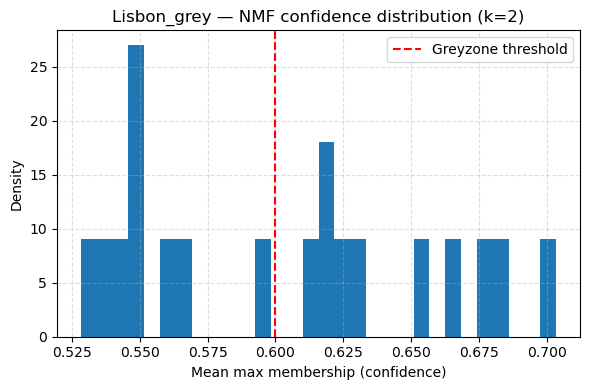

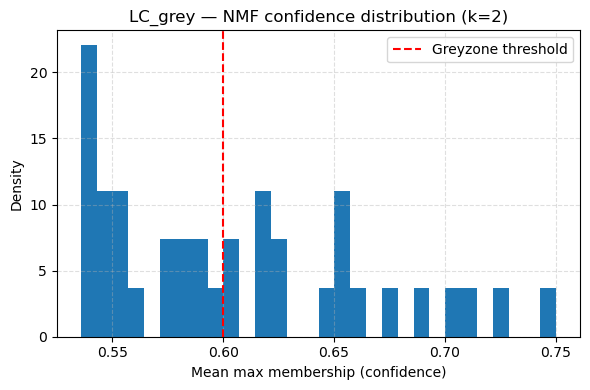

In [60]:
# ─────────────────────────
# NMF ONLY ON GREY PATIENTS
# ─────────────────────────

nmf_grey_results = {}

nmf_grey_results["Coimbra"] = nmf_k2_analysis(
    Coimbra_grey_df,
    "Coimbra_grey"
)

nmf_grey_results["Lisbon"] = nmf_k2_analysis(
    Lisbon_grey_df,
    "Lisbon_grey"
)

nmf_grey_results["LC"] = nmf_k2_analysis(
    LC_grey_df,
    "LC_grey"
)
coimbra_features_grey = nmf_k2_results["Coimbra"][3]

lisbon_features_grey = nmf_k2_results["Lisbon"][3]

lc_features_grey = nmf_k2_results["LC"][3]
# Coimbra
plot_nmf_k2_membership_distribution(
    nmf_grey_results["Coimbra"][1],
    "Coimbra_grey"
)

# Lisbon
plot_nmf_k2_membership_distribution(
    nmf_grey_results["Lisbon"][1],
    "Lisbon_grey"
)

# LC
plot_nmf_k2_membership_distribution(
    nmf_grey_results["LC"][1],
    "LC_grey"
)

In [74]:
coimbra_features_grey = nmf_grey_results["Coimbra"][3]

lisbon_features_grey = nmf_grey_results["Lisbon"][3]

lc_features_grey = nmf_grey_results["LC"][3]


coimbra_cluster0_grey = coimbra_features_grey[0].index.tolist()
coimbra_cluster1_grey = coimbra_features_grey[1].index.tolist()


lisbon_cluster0_grey = lisbon_features_grey[0].index.tolist()
lisbon_cluster1_grey = lisbon_features_grey[1].index.tolist()


lc_cluster0_grey = lc_features_grey[0].index.tolist()
lc_cluster1_grey = lc_features_grey[1].index.tolist()

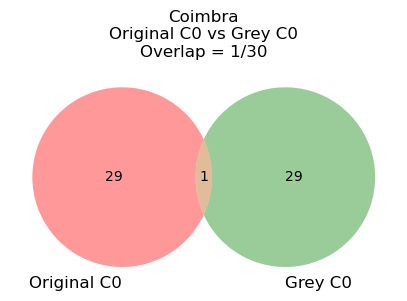

Coimbra | Original C0 vs Grey C0 -> overlap = 1/30


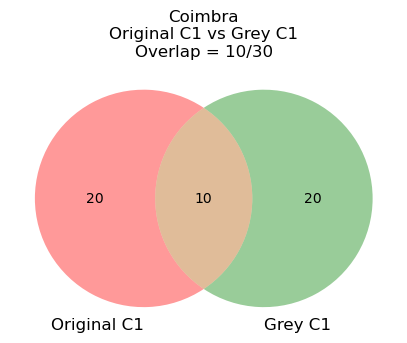

Coimbra | Original C1 vs Grey C1 -> overlap = 10/30


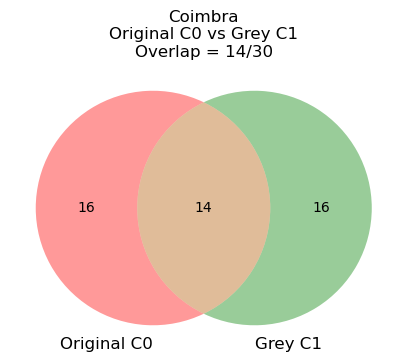

Coimbra | Original C0 vs Grey C1 -> overlap = 14/30


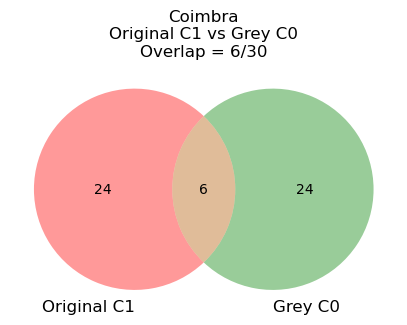

Coimbra | Original C1 vs Grey C0 -> overlap = 6/30


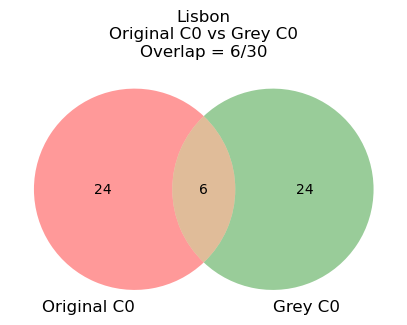

Lisbon | Original C0 vs Grey C0 -> overlap = 6/30


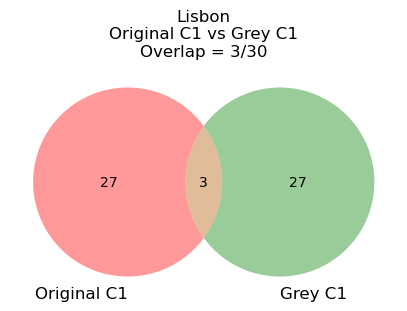

Lisbon | Original C1 vs Grey C1 -> overlap = 3/30


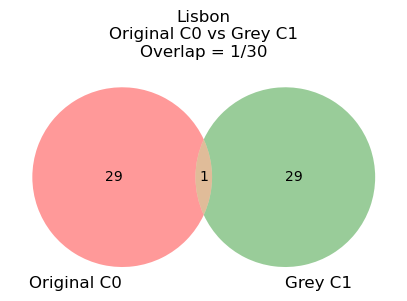

Lisbon | Original C0 vs Grey C1 -> overlap = 1/30


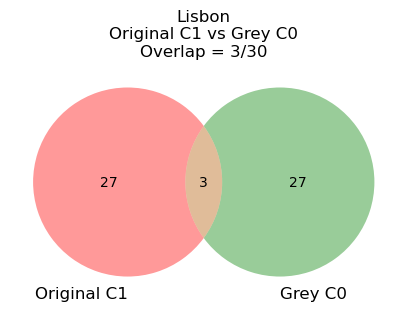

Lisbon | Original C1 vs Grey C0 -> overlap = 3/30


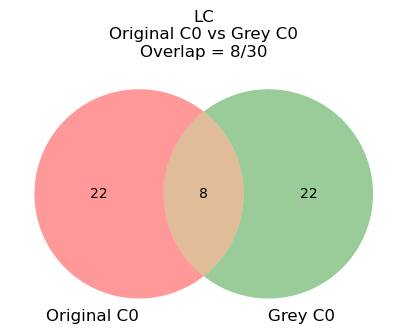

LC | Original C0 vs Grey C0 -> overlap = 8/30


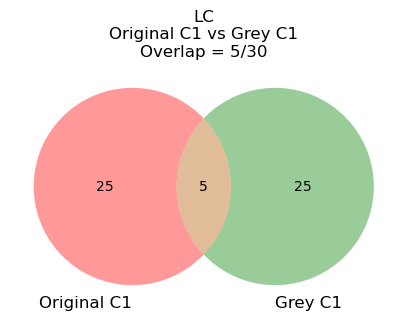

LC | Original C1 vs Grey C1 -> overlap = 5/30


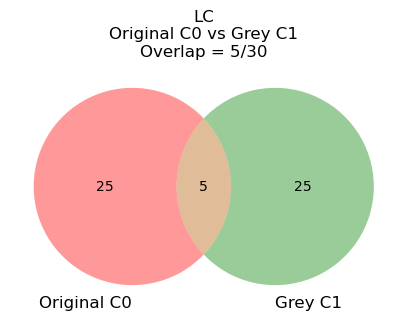

LC | Original C0 vs Grey C1 -> overlap = 5/30


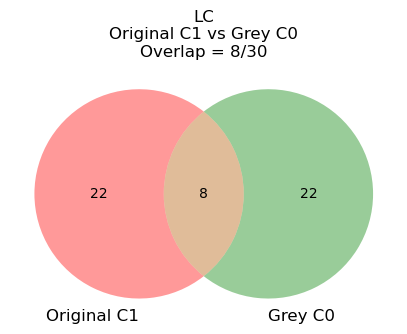

LC | Original C1 vs Grey C0 -> overlap = 8/30


In [77]:
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

# ─────────────────────────
# CROSS CLUSTER OVERLAP
# ─────────────────────────

datasets = {
    "Coimbra": (
        coimbra_cluster0,
        coimbra_cluster1,
        coimbra_cluster0_grey,
        coimbra_cluster1_grey
    ),

    "Lisbon": (
        lisbon_cluster0,
        lisbon_cluster1,
        lisbon_cluster0_grey,
        lisbon_cluster1_grey
    ),

    "LC": (
        lc_cluster0,
        lc_cluster1,
        lc_cluster0_grey,
        lc_cluster1_grey
    )
}

for name, (
    c0,
    c1,
    c0_grey,
    c1_grey
) in datasets.items():

    comparisons = [

        ("Original C0", "Grey C0", c0, c0_grey),
        ("Original C1", "Grey C1", c1, c1_grey),

        ("Original C0", "Grey C1", c0, c1_grey),
        ("Original C1", "Grey C0", c1, c0_grey),
    ]

    for label1, label2, set1, set2 in comparisons:

        overlap = len(set(set1) & set(set2))

        plt.figure(figsize=(5,5))

        venn2(
            [set(set1), set(set2)],
            set_labels=(label1, label2)
        )

        plt.title(
            f"{name}\n"
            f"{label1} vs {label2}\n"
            f"Overlap = {overlap}/30"
        )

        plt.show()

        print(
            f"{name} | "
            f"{label1} vs {label2} "
            f"-> overlap = {overlap}/30"
        )

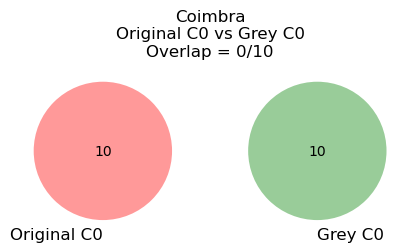

Coimbra | Original C0 vs Grey C0 -> overlap = 0/10


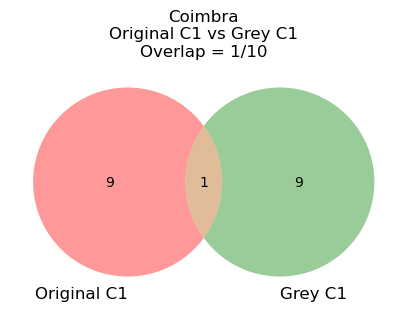

Coimbra | Original C1 vs Grey C1 -> overlap = 1/10


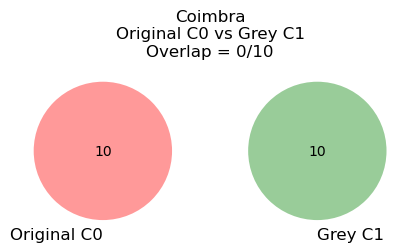

Coimbra | Original C0 vs Grey C1 -> overlap = 0/10


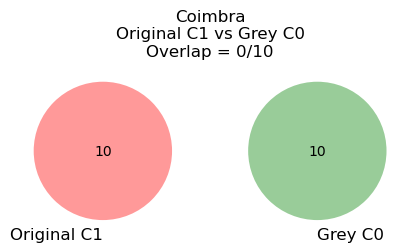

Coimbra | Original C1 vs Grey C0 -> overlap = 0/10


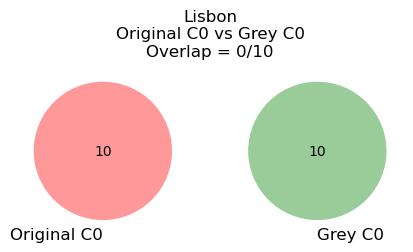

Lisbon | Original C0 vs Grey C0 -> overlap = 0/10


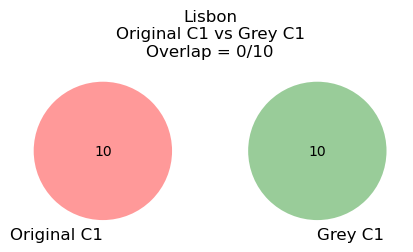

Lisbon | Original C1 vs Grey C1 -> overlap = 0/10


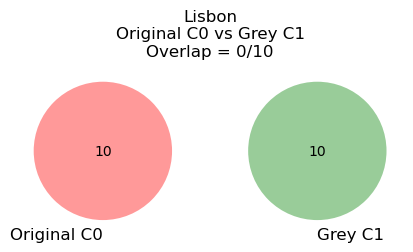

Lisbon | Original C0 vs Grey C1 -> overlap = 0/10


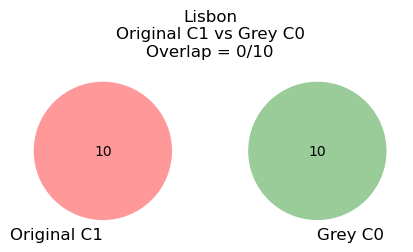

Lisbon | Original C1 vs Grey C0 -> overlap = 0/10


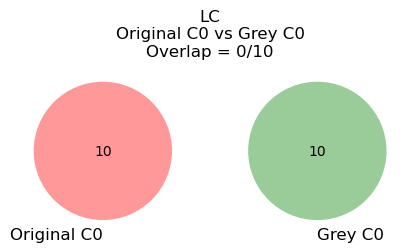

LC | Original C0 vs Grey C0 -> overlap = 0/10


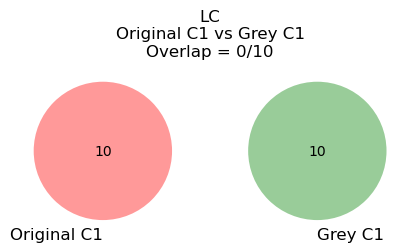

LC | Original C1 vs Grey C1 -> overlap = 0/10


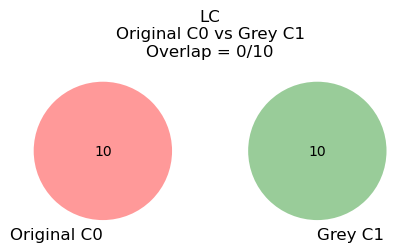

LC | Original C0 vs Grey C1 -> overlap = 0/10


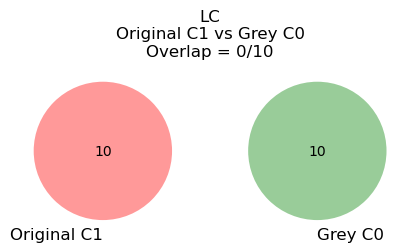

LC | Original C1 vs Grey C0 -> overlap = 0/10


In [78]:
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

# ─────────────────────────
# TOP 10 FEATURES
# ─────────────────────────

coimbra_cluster0_top10 = coimbra_cluster0[:10]
coimbra_cluster1_top10 = coimbra_cluster1[:10]

coimbra_cluster0_grey_top10 = coimbra_cluster0_grey[:10]
coimbra_cluster1_grey_top10 = coimbra_cluster1_grey[:10]


lisbon_cluster0_top10 = lisbon_cluster0[:10]
lisbon_cluster1_top10 = lisbon_cluster1[:10]

lisbon_cluster0_grey_top10 = lisbon_cluster0_grey[:10]
lisbon_cluster1_grey_top10 = lisbon_cluster1_grey[:10]


lc_cluster0_top10 = lc_cluster0[:10]
lc_cluster1_top10 = lc_cluster1[:10]

lc_cluster0_grey_top10 = lc_cluster0_grey[:10]
lc_cluster1_grey_top10 = lc_cluster1_grey[:10]

# ─────────────────────────
# VENN DIAGRAMS
# ─────────────────────────

datasets = {
    "Coimbra": (
        coimbra_cluster0_top10,
        coimbra_cluster1_top10,
        coimbra_cluster0_grey_top10,
        coimbra_cluster1_grey_top10
    ),

    "Lisbon": (
        lisbon_cluster0_top10,
        lisbon_cluster1_top10,
        lisbon_cluster0_grey_top10,
        lisbon_cluster1_grey_top10
    ),

    "LC": (
        lc_cluster0_top10,
        lc_cluster1_top10,
        lc_cluster0_grey_top10,
        lc_cluster1_grey_top10
    )
}

for name, (
    c0,
    c1,
    c0_grey,
    c1_grey
) in datasets.items():

    comparisons = [

        ("Original C0", "Grey C0", c0, c0_grey),
        ("Original C1", "Grey C1", c1, c1_grey),

        ("Original C0", "Grey C1", c0, c1_grey),
        ("Original C1", "Grey C0", c1, c0_grey),
    ]

    for label1, label2, set1, set2 in comparisons:

        overlap = len(set(set1) & set(set2))

        plt.figure(figsize=(5,5))

        venn2(
            [set(set1), set(set2)],
            set_labels=(label1, label2)
        )

        plt.title(
            f"{name}\n"
            f"{label1} vs {label2}\n"
            f"Overlap = {overlap}/10"
        )

        plt.show()

        print(
            f"{name} | "
            f"{label1} vs {label2} "
            f"-> overlap = {overlap}/10"
        )

In [32]:
import numpy as np
from sklearn.decomposition import NMF
from sklearn.metrics import silhouette_score, adjusted_rand_score, calinski_harabasz_score, davies_bouldin_score
from scipy.cluster.hierarchy import linkage, cophenet
from scipy.spatial.distance import pdist
import pandas as pd



def nmf_grey_cluster_analysis(labels, df, patients_grey, name):

    import numpy as np

    print(f"\n{'='*60}")
    print(f"{name} — GREY ANALYSIS (NMF, k=2)")
    print(f"{'='*60}")

    labels = np.array(labels)

    grey_set = set(patients_grey)
    patients = df.index.tolist()
    is_grey = np.array([1 if p in grey_set else 0 for p in patients])

    clusters = sorted(np.unique(labels))

    # errore binomiale (%)
    def binomial_std(p, n):
        return np.sqrt(p * (1 - p) / n) * 100 if n > 0 else 0

    # ─────────────────────────
    # 1) CLUSTER COMPOSITION
    # ─────────────────────────
    print("\n[1] Cluster composition (% grey inside cluster)")

    for c in clusters:
        mask = labels == c
        n = mask.sum()

        if n == 0:
            continue

        p = is_grey[mask].mean()
        perc = p * 100
        std  = binomial_std(p, n)

        print(f"\nCluster {c} ({n} patients):")
        print(f"  Grey:     {perc:.1f}% ± {std:.1f}%")
        print(f"  Non-grey: {100 - perc:.1f}% ± {std:.1f}%")

    # ─────────────────────────
    # 2) DISTRIBUTION OF GREY
    # ─────────────────────────
    print("\n[2] Distribution of grey patients (% of ALL grey)")

    grey_total = len(grey_set)

    for c in clusters:
        mask = labels == c

        grey_in_cluster = np.sum(is_grey[mask])

        p = grey_in_cluster / grey_total if grey_total > 0 else 0
        perc = p * 100
        std  = binomial_std(p, grey_total)

        print(f"\nCluster {c}:")
        print(f"  % of ALL grey = {perc:.1f}% ± {std:.1f}%")

# ─────────────────────────────────────────────
# MULTI-RUN NMF (WITH W STORAGE)
# ─────────────────────────────────────────────
def run_nmf_multiple(X, k, n_runs=60):
    labels_list = []
    errors = []
    models = []
    W_list = []

    for seed in range(n_runs):
        nmf = NMF(
            n_components=k,
            init='random',
            max_iter=10000,
            random_state=seed
        )
        
        W = nmf.fit_transform(X)

        # 🔥 normalize row-wise
        W_norm = W / W.sum(axis=1, keepdims=True)

        labels = np.argmax(W_norm, axis=1)
        
        labels_list.append(labels)
        errors.append(nmf.reconstruction_err_)
        models.append(nmf)
        W_list.append(W_norm)

    return np.array(labels_list), np.array(errors), models, np.array(W_list)


# ─────────────────────────────────────────────
# CONSENSUS + COPHENETIC
# ─────────────────────────────────────────────
def compute_consensus_matrix(labels_list):
    n_runs, n_samples = labels_list.shape
    consensus = np.zeros((n_samples, n_samples))

    for labels in labels_list:
        for i in range(n_samples):
            for j in range(n_samples):
                if labels[i] == labels[j]:
                    consensus[i, j] += 1

    consensus /= n_runs
    return consensus


def compute_cophenetic(consensus):
    distance = 1 - consensus
    dist_vec = pdist(distance)
    linkage_matrix = linkage(dist_vec, method='average')
    coph_corr, _ = cophenet(linkage_matrix, dist_vec)
    return coph_corr


# ─────────────────────────────────────────────
# METRICS
# ─────────────────────────────────────────────
def compute_random_silhouette(X, k):
    random_labels = np.random.randint(0, k, size=X.shape[0])
    return silhouette_score(X, random_labels)


def compute_ari_stability(labels_list):
    n_runs = labels_list.shape[0]
    ari_vals = []

    for i in range(n_runs):
        for j in range(i + 1, n_runs):
            ari_vals.append(
                adjusted_rand_score(labels_list[i], labels_list[j])
            )

    ari_vals = np.array(ari_vals)

    return {
        "ari_mean": ari_vals.mean(),
        "ari_std": ari_vals.std(),
        "ari_min": ari_vals.min()
    }




def nmf_dataset_composition(labels, df, name):

    import pandas as pd
    import numpy as np

    print(f"\n{'='*60}")
    print(f"{name} — Dataset composition (NMF, k=2)")
    print(f"{'='*60}")

    labels = np.array(labels)

    df_clusters = pd.DataFrame({
        "cluster": labels,
        "patient": df.index
    })

    # 🔥 definizione origine
    def get_origin(p):
        return "Lisbon" if str(p).startswith("LIS") else "Coimbra"

    df_clusters["origin"] = df_clusters["patient"].apply(get_origin)

    # ─────────────────────────
    # stampa percentuali
    # ─────────────────────────
    for c in sorted(df_clusters["cluster"].unique()):
        subset = df_clusters[df_clusters["cluster"] == c]

        counts = subset["origin"].value_counts(normalize=True) * 100

        print(f"\nCluster {c} ({len(subset)} patients):")
        print(f"  Lisbon:  {counts.get('Lisbon', 0):.1f}%")
        print(f"  Coimbra: {counts.get('Coimbra', 0):.1f}%")


# ─────────────────────────────────────────────
# 🔥 NEW: PATIENT STABILITY
# ─────────────────────────────────────────────
def compute_patient_stability(W_list):
    max_memberships = W_list.max(axis=2)  # (runs, samples)

    mean_conf = max_memberships.mean(axis=0)
    std_conf  = max_memberships.std(axis=0)

    return mean_conf, std_conf


# ─────────────────────────────────────────────
# MAIN PIPELINE
# ─────────────────────────────────────────────
def nmf_stability_pipeline(X, k_range, feature_names=None, n_runs=60):
    results = {}
    labels_dict = {}

    for k in k_range:
        print(f"Running k={k}...")

        labels_list, errors, models, W_list = run_nmf_multiple(X, k, n_runs)

        # ARI
        ari_stats = compute_ari_stability(labels_list)

        best_idx = np.argmin(errors)
        best_model = models[best_idx]
        H = best_model.components_

        W = best_model.transform(X)
        W_norm = W / W.sum(axis=1, keepdims=True)
        labels = np.argmax(W_norm, axis=1)

        labels_dict[k] = labels
        
        if feature_names is None:
            feature_names = [f"Feature_{i}" for i in range(X.shape[1])]

        # ─────────────────────────────
        # CONSENSUS TOP FEATURES ACROSS RUNS
        # ─────────────────────────────
        
        print("\n=== CONSENSUS TOP FEATURES ===")
        
        top_n = 30
        
        # inizializza strutture
        feature_frequency = {
            c: pd.Series(0, index=feature_names, dtype=float)
            for c in range(k)
        }
        
        feature_rank_sum = {
            c: pd.Series(0, index=feature_names, dtype=float)
            for c in range(k)
        }
        
        # ─────────────────────────────
        # ALIGNMENT USING HUNGARIAN MATCHING
        # ─────────────────────────────
        
        from scipy.optimize import linear_sum_assignment
        
        # modello di riferimento
        H_ref = models[0].components_
        
        # accumula ranking across aligned runs
        for model in models:
        
            H_run = model.components_
        
            # ─────────────────────────
            # cost matrix
            # ─────────────────────────
            cost = np.zeros((k, k))
        
            for i in range(k):
                for j in range(k):
        
                    # distanza tra componenti
                    cost[i, j] = np.linalg.norm(
                        H_ref[i] - H_run[j]
                    )
        
            # Hungarian matching
            _, col_ind = linear_sum_assignment(cost)
        
            # componenti allineate
            H_aligned = H_run[col_ind]
        
            # ─────────────────────────
            # ranking features
            # ─────────────────────────
            for c in range(k):
        
                ranked_idx = np.argsort(
                    H_aligned[c]
                )[::-1][:top_n]
        
                for rank, idx in enumerate(
                    ranked_idx,
                    start=1
                ):
        
                    feat = feature_names[idx]
        
                    # frequenza
                    feature_frequency[c][feat] += 1
        
                    # somma rank
                    feature_rank_sum[c][feat] += rank
        
        # stampa risultati
        for c in range(k):
        
            print(f"\n--- Cluster {c} ---")
        
            df_features = pd.DataFrame({
                "frequency": feature_frequency[c],
                "rank_sum": feature_rank_sum[c]
            })
        
            # tieni solo feature comparse almeno una volta
            df_features = df_features[
                df_features["frequency"] > 0
            ]
        
            # rank medio
            df_features["mean_rank"] = (
                df_features["rank_sum"]
                / df_features["frequency"]
            )
        
            # ordina:
            # 1) frequenza alta
            # 2) rank medio basso
            df_features = df_features.sort_values(
                by=["frequency", "mean_rank"],
                ascending=[False, True]
            )
        
            # top 30 finali
            df_top = df_features.head(30)
        
            for i, (feat, row) in enumerate(
                df_top.iterrows(),
                start=1
            ):
        
                print(
                    f"{i:02d}. "
                    f"{feat} | "
                    f"freq={int(row['frequency'])}/{n_runs} | "
                    f"mean_rank={row['mean_rank']:.2f}"
                )

        # ── Patients per cluster
        print("\n--- Patients per cluster ---")
        for cluster in range(k):
            patients = X.index[labels == cluster]
            print(f"\nCluster {cluster}:")
            print(patients)

        # ─────────────────────────────
        # 🔥 PATIENT STABILITY ANALYSIS
        # ─────────────────────────────
        mean_conf, std_conf = compute_patient_stability(W_list)

        df_membership = pd.DataFrame({
            "mean_membership": mean_conf,
            "std_membership": std_conf,
            "cluster": labels
        }, index=X.index)

        # 🔥 categories
        df_membership["category"] = pd.cut(
            df_membership["mean_membership"],
            bins=[0.5, 0.6, 0.7, 1.0],
            labels=["greyzone (0.5-0.6)", "borderline (0.6-0.7)", "clear (>0.7)"]
        )

        print("\n=== Membership Stability Summary ===")
        print(df_membership["category"].value_counts())

        print("\n=== Mean ± STD per category ===")
        print(df_membership.groupby("category")[["mean_membership", "std_membership"]].mean())

        # 🔥 patient lists
        greyzone = df_membership[df_membership["category"] == "greyzone (0.5-0.6)"].index.tolist()
        borderline = df_membership[df_membership["category"] == "borderline (0.6-0.7)"].index.tolist()
        clear = df_membership[df_membership["category"] == "clear (>0.7)"].index.tolist()

        if k == 2:
            print("\n🔴 Greyzone patients (k=2):")
            print(greyzone)
        
            print("\n🟡 Borderline patients (k=2):")
            print(borderline)
        
            print("\n🟢 Clear patients (k=2):")
            print(clear)
        
            # 🔥 AUTOMATIC GREY ANALYSIS (NMF)
            nmf_grey_cluster_analysis(
                labels=labels,
                df=X,
                patients_grey=greyzone,
                name="NMF"
            )
            nmf_dataset_composition(
                labels=labels,
                df=X,
                name="NMF"
            )

        # ─────────────────────────────
        # METRICS
        # ─────────────────────────────
        consensus = compute_consensus_matrix(labels_list)
        cophenetic = compute_cophenetic(consensus)

        sil_vals = []
        ch_vals  = []
        db_vals  = []
        
        for lbls in labels_list:
            sil_vals.append(silhouette_score(X, lbls))
            ch_vals.append(calinski_harabasz_score(X, lbls))
            db_vals.append(davies_bouldin_score(X, lbls))
        
        sil_real = np.mean(sil_vals)
        ch_mean  = np.mean(ch_vals)
        db_mean  = np.mean(db_vals)
        sil_random = compute_random_silhouette(X, k)

        results[k] = {
            "cophenetic": cophenetic,
            "silhouette": sil_real,
            "silhouette_random": sil_random,
            "gap": sil_real - sil_random,
            "error_mean": np.mean(errors),
            "error_std": np.std(errors),
            "ari_mean": ari_stats["ari_mean"],
            "ari_std": ari_stats["ari_std"],
            "ari_min": ari_stats["ari_min"],
            "CH": ch_mean,
            "DB": db_mean,
        }

    # ─────────────────────────────
    # POST-PROCESSING
    # ─────────────────────────────
    df_results = pd.DataFrame(results).T
    df_results.index.name = "k"
    df_results = df_results.sort_index()

    df_results["delta_error"] = df_results["error_mean"].shift(1) - df_results["error_mean"]
    df_results["perc_variance_explained"] = df_results["delta_error"] / df_results["error_mean"].shift(1)

    n_random = 30  
    random_errors = {}
    
    for k_val in df_results.index:
        rand_errs = []
    
        for _ in range(n_random):
            X_random = X.apply(np.random.permutation)
            _, errors_rand, _, _ = run_nmf_multiple(X_random, k_val, n_runs=5)
            rand_errs.append(np.mean(errors_rand))
    
        random_errors[k_val] = np.mean(rand_errs)

    df_results["random_error"] = pd.Series(random_errors)
    df_results["delta_error_random"] = df_results["random_error"].shift(1) - df_results["random_error"]
    df_results["perc_variance_random"] = df_results["delta_error_random"] / df_results["random_error"].shift(1)

    df_results["fold_improvement"] = (
        df_results["perc_variance_explained"] / df_results["perc_variance_random"]
    )

    df_results = df_results.round(4)

    return df_results, labels_dict

def plot_global_membership_distribution(
    W_list,
    title="Global membership confidence",
    dataset_name=None,
    save=True,
    output_dir="."
):

    # max membership per run e paziente
    max_memberships = W_list.max(axis=2)  # (runs, samples)

    # ✅ MEDIA per paziente
    values = max_memberships.mean(axis=0)

    plt.figure(figsize=(6, 4))
    plt.hist(values, bins=30, density=True)

    plt.axvline(0.6, linestyle="--", color='red', label="Greyzone threshold")

    plt.xlabel("Mean max membership (confidence)")
    plt.ylabel("Density")
    plt.title(title)

    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()

    if save:
        if dataset_name:
            filename = f"{dataset_name}_NMF_membership_distribution_mean.png"
        else:
            filename = "NMF_membership_distribution_mean.png"

        filepath = os.path.join(output_dir, filename)
        plt.savefig(filepath, dpi=300)

    plt.show()

Running k=2...

=== CONSENSUS TOP FEATURES ===

--- Cluster 0 ---
01. P04264 | freq=60/60 | mean_rank=1.48
02. P13645 | freq=60/60 | mean_rank=1.52
03. P25311 | freq=60/60 | mean_rank=3.00
04. P02763 | freq=60/60 | mean_rank=4.38
05. Q8N2S1 | freq=60/60 | mean_rank=4.62
06. Q14515 | freq=60/60 | mean_rank=6.40
07. P42785 | freq=60/60 | mean_rank=6.60
08. P27169 | freq=60/60 | mean_rank=8.00
09. Q9UBP4 | freq=60/60 | mean_rank=9.00
10. O15031 | freq=60/60 | mean_rank=10.00
11. Q96IY4 | freq=60/60 | mean_rank=11.13
12. P02750 | freq=60/60 | mean_rank=11.90
13. P02765 | freq=60/60 | mean_rank=13.40
14. P06733 | freq=60/60 | mean_rank=13.57
15. Q6UXD5 | freq=60/60 | mean_rank=15.58
16. P19652 | freq=60/60 | mean_rank=15.60
17. P19827 | freq=60/60 | mean_rank=16.98
18. Q14624 | freq=60/60 | mean_rank=18.05
19. P51693 | freq=60/60 | mean_rank=19.27
20. P06727 | freq=60/60 | mean_rank=19.57
21. P05067 | freq=60/60 | mean_rank=21.18
22. Q9H3G5 | freq=60/60 | mean_rank=21.88
23. P35858 | freq=6

/tmp/ipykernel_20673/2417112352.py:377: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_membership.groupby("category")[["mean_membership", "std_membership"]].mean())


Running k=3...

=== CONSENSUS TOP FEATURES ===

--- Cluster 0 ---
01. Q12805 | freq=56/60 | mean_rank=8.68
02. P01034 | freq=56/60 | mean_rank=9.82
03. Q99435 | freq=52/60 | mean_rank=10.25
04. Q96GW7 | freq=49/60 | mean_rank=4.47
05. Q8NFZ8 | freq=48/60 | mean_rank=13.79
06. P07998 | freq=47/60 | mean_rank=4.70
07. P54764 | freq=46/60 | mean_rank=11.09
08. P14618 | freq=45/60 | mean_rank=5.78
09. O43505 | freq=45/60 | mean_rank=6.47
10. O75326 | freq=45/60 | mean_rank=10.82
11. P02787 | freq=45/60 | mean_rank=15.27
12. Q7Z3B1 | freq=45/60 | mean_rank=20.84
13. Q9NQ79 | freq=44/60 | mean_rank=9.32
14. O14594 | freq=43/60 | mean_rank=12.42
15. P10643 | freq=42/60 | mean_rank=13.48
16. P13591 | freq=41/60 | mean_rank=12.27
17. Q12860 | freq=41/60 | mean_rank=18.85
18. P06396 | freq=41/60 | mean_rank=21.95
19. P00736 | freq=40/60 | mean_rank=7.62
20. P23142 | freq=38/60 | mean_rank=14.11
21. Q9C0A0 | freq=37/60 | mean_rank=13.86
22. O95967 | freq=34/60 | mean_rank=11.38
23. P36222 | freq=

/tmp/ipykernel_20673/2417112352.py:377: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_membership.groupby("category")[["mean_membership", "std_membership"]].mean())


Running k=4...

=== CONSENSUS TOP FEATURES ===

--- Cluster 0 ---
01. Q96GW7 | freq=53/60 | mean_rank=4.23
02. O43505 | freq=53/60 | mean_rank=9.15
03. O75326 | freq=49/60 | mean_rank=12.24
04. P02787 | freq=49/60 | mean_rank=15.69
05. Q12805 | freq=48/60 | mean_rank=9.88
06. P13591 | freq=46/60 | mean_rank=11.22
07. P14618 | freq=45/60 | mean_rank=5.42
08. Q99435 | freq=45/60 | mean_rank=11.49
09. Q12860 | freq=43/60 | mean_rank=19.00
10. O14594 | freq=42/60 | mean_rank=10.60
11. Q9NQ79 | freq=41/60 | mean_rank=7.80
12. P54764 | freq=40/60 | mean_rank=11.18
13. P01034 | freq=40/60 | mean_rank=13.07
14. Q9C0A0 | freq=39/60 | mean_rank=10.79
15. P06396 | freq=37/60 | mean_rank=17.84
16. P48058 | freq=36/60 | mean_rank=19.19
17. P07998 | freq=35/60 | mean_rank=9.06
18. O94985 | freq=35/60 | mean_rank=9.40
19. P00738 | freq=35/60 | mean_rank=13.11
20. Q8NFZ8 | freq=35/60 | mean_rank=13.20
21. Q8IV08 | freq=32/60 | mean_rank=20.62
22. O94856 | freq=32/60 | mean_rank=23.38
23. Q9ULB1 | freq

/tmp/ipykernel_20673/2417112352.py:377: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_membership.groupby("category")[["mean_membership", "std_membership"]].mean())


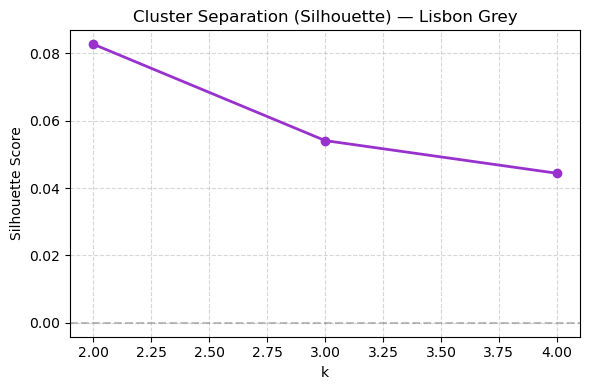

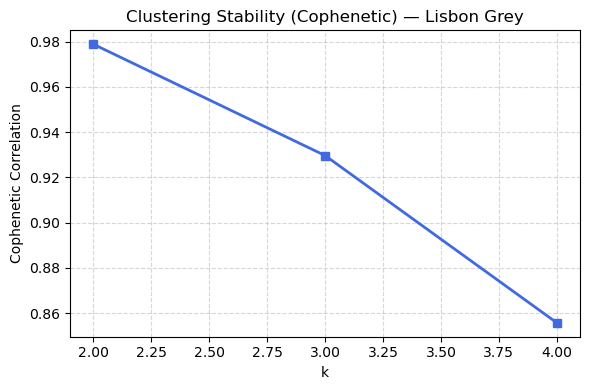

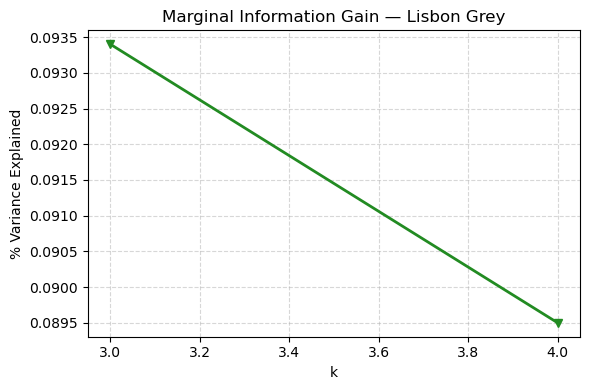

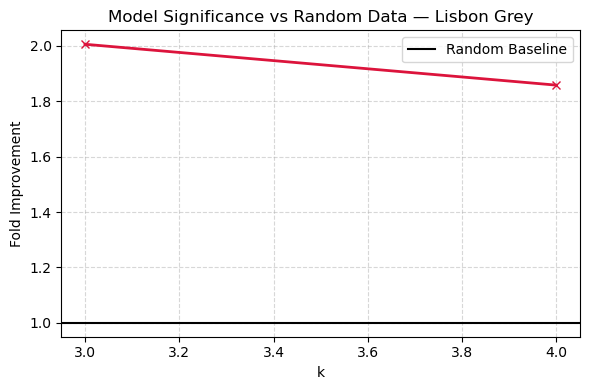

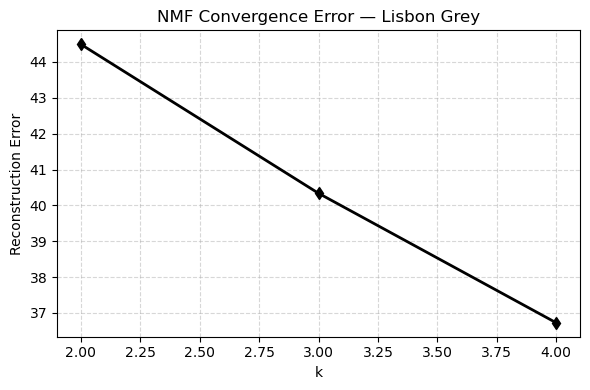

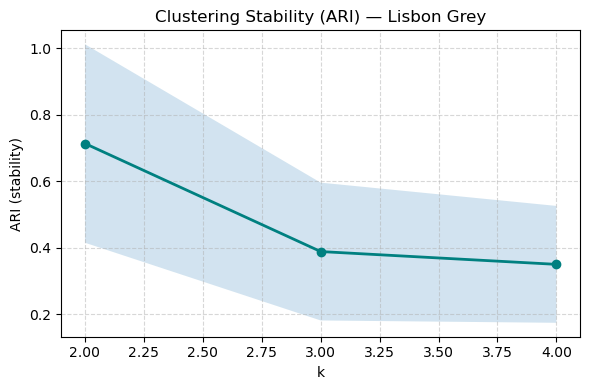

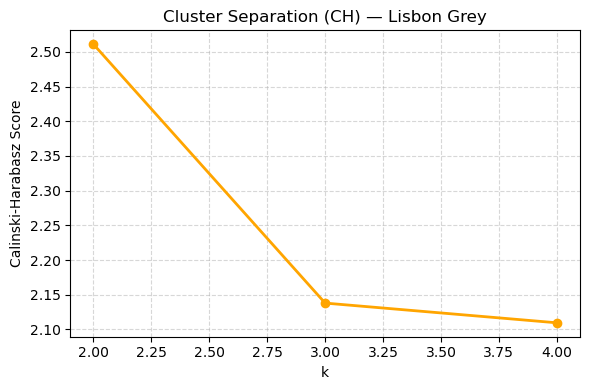

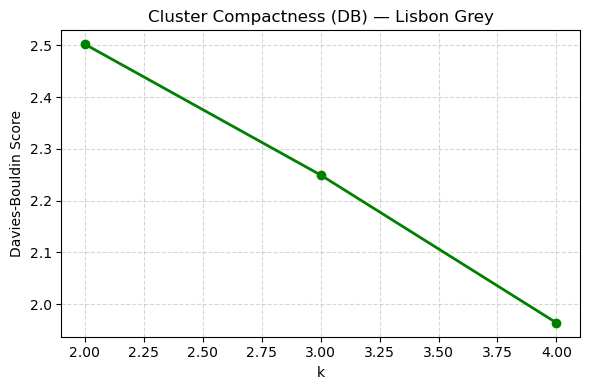

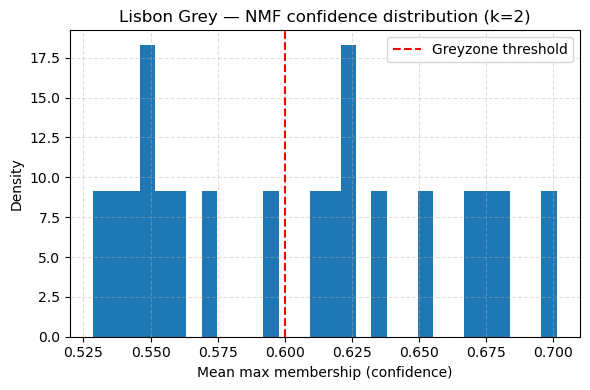

In [34]:
k_range = [2, 3, 4]

results_nmf_Lisbon_grey, labels_nmf_Lisbon_grey = nmf_stability_pipeline(
    Lisbon_grey_df,
    k_range,
    feature_names=proteins_present_Lisbon,
    n_runs=60
)

import matplotlib.pyplot as plt

# Definiamo i dati dai tuoi risultati
ks = results_nmf_Lisbon_grey.index

# 1. SILHOUETTE SCORE
plt.figure(figsize=(6, 4))
plt.plot(
    ks,
    results_nmf_Lisbon_grey["silhouette"],
    marker='o',
    color='darkorchid',
    linewidth=2
)

plt.axhline(0, color='gray', linestyle='--', alpha=0.5)

plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Cluster Separation (Silhouette) — Lisbon Grey")

plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig('Silhouette_Score_Lisbon_Grey')

plt.show()

# 2. COPHENETIC CORRELATION
plt.figure(figsize=(6, 4))

plt.plot(
    ks,
    results_nmf_Lisbon_grey["cophenetic"],
    marker='s',
    color='royalblue',
    linewidth=2
)

plt.xlabel("k")
plt.ylabel("Cophenetic Correlation")
plt.title("Clustering Stability (Cophenetic) — Lisbon Grey")

plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig('Cophenetic_Correlation_Lisbon_Grey')

plt.show()

# 3. % VARIANCE EXPLAINED
plt.figure(figsize=(6, 4))

plt.plot(
    ks,
    results_nmf_Lisbon_grey["perc_variance_explained"],
    marker='v',
    color='forestgreen',
    linewidth=2
)

plt.xlabel("k")
plt.ylabel("% Variance Explained")
plt.title("Marginal Information Gain — Lisbon Grey")

plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig('Marginal_information_gain_Lisbon_Grey')

plt.show()

# 4. FOLD IMPROVEMENT
plt.figure(figsize=(6, 4))

plt.plot(
    ks,
    results_nmf_Lisbon_grey["fold_improvement"],
    marker='x',
    color='crimson',
    linewidth=2
)

plt.axhline(
    1,
    color='black',
    linestyle='-',
    label="Random Baseline"
)

plt.xlabel("k")
plt.ylabel("Fold Improvement")
plt.title("Model Significance vs Random Data — Lisbon Grey")

plt.legend()

plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig('Model_Significance_vs_Random_Data_Lisbon_Grey')

plt.show()

# 5. RECONSTRUCTION ERROR
plt.figure(figsize=(6, 4))

plt.plot(
    ks,
    results_nmf_Lisbon_grey["error_mean"],
    marker='d',
    color='black',
    linewidth=2
)

plt.xlabel("k")
plt.ylabel("Reconstruction Error")
plt.title("NMF Convergence Error — Lisbon Grey")

plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig('NMF_converge_error_Lisbon_Grey')

plt.show()

# 6. ARI STABILITY
plt.figure(figsize=(6, 4))

plt.plot(
    ks,
    results_nmf_Lisbon_grey["ari_mean"],
    marker='o',
    color='teal',
    linewidth=2
)

plt.fill_between(
    ks,
    results_nmf_Lisbon_grey["ari_mean"] - results_nmf_Lisbon_grey["ari_std"],
    results_nmf_Lisbon_grey["ari_mean"] + results_nmf_Lisbon_grey["ari_std"],
    alpha=0.2
)

plt.xlabel("k")
plt.ylabel("ARI (stability)")
plt.title("Clustering Stability (ARI) — Lisbon Grey")

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig('ARI_Stability_Lisbon_Grey')

plt.show()

# 7. CALINSKI-HARABASZ
plt.figure(figsize=(6, 4))

plt.plot(
    ks,
    results_nmf_Lisbon_grey["CH"],
    marker='o',
    color='orange',
    linewidth=2
)

plt.xlabel("k")
plt.ylabel("Calinski-Harabasz Score")
plt.title("Cluster Separation (CH) — Lisbon Grey")

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig('CH_Score_Lisbon_Grey')

plt.show()

# 8. DAVIES-BOULDIN
plt.figure(figsize=(6, 4))

plt.plot(
    ks,
    results_nmf_Lisbon_grey["DB"],
    marker='o',
    color='green',
    linewidth=2
)

plt.xlabel("k")
plt.ylabel("Davies-Bouldin Score")
plt.title("Cluster Compactness (DB) — Lisbon Grey")

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig('DB_Score_Lisbon_Grey')

plt.show()

# 9. MEMBERSHIP DISTRIBUTION
k = 2

labels_list, errors, models, W_list = run_nmf_multiple(
    Lisbon_grey_df,
    k,
    n_runs=60
)

plot_global_membership_distribution(
    W_list,
    title="Lisbon Grey — NMF confidence distribution (k=2)",
    dataset_name="Lisbon_Grey",
    output_dir="NMF_confidence_distribution/"
)

Running k=2...

=== CONSENSUS TOP FEATURES ===

--- Cluster 0 ---
01. P23515 | freq=60/60 | mean_rank=1.00
02. P61916 | freq=60/60 | mean_rank=2.08
03. Q99574 | freq=60/60 | mean_rank=2.92
04. P04216 | freq=60/60 | mean_rank=4.00
05. Q96GW7 | freq=60/60 | mean_rank=5.12
06. O75326 | freq=60/60 | mean_rank=5.88
07. Q12805 | freq=60/60 | mean_rank=7.87
08. Q9Y4C0 | freq=60/60 | mean_rank=7.93
09. Q6MZW2 | freq=60/60 | mean_rank=8.32
10. P04180 | freq=60/60 | mean_rank=9.88
11. P07998 | freq=60/60 | mean_rank=11.28
12. P02747 | freq=60/60 | mean_rank=11.72
13. Q9NT99 | freq=60/60 | mean_rank=13.00
14. P41222 | freq=60/60 | mean_rank=14.00
15. P14618 | freq=60/60 | mean_rank=15.00
16. Q9NQ79 | freq=60/60 | mean_rank=16.00
17. P00736 | freq=60/60 | mean_rank=17.08
18. P01034 | freq=60/60 | mean_rank=18.25
19. P23142 | freq=60/60 | mean_rank=18.68
20. Q15818 | freq=60/60 | mean_rank=19.98
21. P02746 | freq=60/60 | mean_rank=21.00
22. P05067 | freq=60/60 | mean_rank=22.42
23. Q14982 | freq=60

/tmp/ipykernel_20673/2417112352.py:377: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_membership.groupby("category")[["mean_membership", "std_membership"]].mean())


Running k=3...

=== CONSENSUS TOP FEATURES ===

--- Cluster 0 ---
01. P00450 | freq=60/60 | mean_rank=7.38
02. P05155 | freq=60/60 | mean_rank=15.15
03. P25311 | freq=59/60 | mean_rank=6.02
04. P01024 | freq=59/60 | mean_rank=18.80
05. P05060 | freq=58/60 | mean_rank=16.41
06. P02750 | freq=56/60 | mean_rank=10.05
07. P01011 | freq=56/60 | mean_rank=14.20
08. P02751 | freq=56/60 | mean_rank=24.07
09. Q9UBP4 | freq=55/60 | mean_rank=16.56
10. P43652 | freq=51/60 | mean_rank=12.67
11. P08294 | freq=51/60 | mean_rank=19.12
12. P01023 | freq=50/60 | mean_rank=8.36
13. P02765 | freq=50/60 | mean_rank=8.96
14. P27169 | freq=49/60 | mean_rank=8.16
15. P02671 | freq=48/60 | mean_rank=23.50
16. P20774 | freq=45/60 | mean_rank=14.69
17. Q14515 | freq=44/60 | mean_rank=11.27
18. P02452 | freq=44/60 | mean_rank=14.75
19. P36955 | freq=43/60 | mean_rank=6.95
20. P55058 | freq=43/60 | mean_rank=9.35
21. P02760 | freq=42/60 | mean_rank=13.29
22. P08123 | freq=42/60 | mean_rank=26.67
23. Q14118 | freq

/tmp/ipykernel_20673/2417112352.py:377: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_membership.groupby("category")[["mean_membership", "std_membership"]].mean())


Running k=4...

=== CONSENSUS TOP FEATURES ===

--- Cluster 0 ---
01. P27169 | freq=57/60 | mean_rank=5.14
02. P05156 | freq=56/60 | mean_rank=7.93
03. P02763 | freq=55/60 | mean_rank=8.11
04. P06727 | freq=55/60 | mean_rank=14.31
05. P01042 | freq=54/60 | mean_rank=15.61
06. P02647 | freq=52/60 | mean_rank=13.13
07. P02765 | freq=50/60 | mean_rank=5.92
08. P04217 | freq=50/60 | mean_rank=12.98
09. P02760 | freq=50/60 | mean_rank=14.46
10. P43652 | freq=49/60 | mean_rank=12.02
11. Q86UX2 | freq=48/60 | mean_rank=15.94
12. P00450 | freq=46/60 | mean_rank=9.61
13. P05155 | freq=46/60 | mean_rank=16.39
14. P01024 | freq=46/60 | mean_rank=18.52
15. P02750 | freq=43/60 | mean_rank=14.51
16. P25311 | freq=42/60 | mean_rank=8.74
17. P02671 | freq=42/60 | mean_rank=20.02
18. P05546 | freq=41/60 | mean_rank=24.51
19. P02753 | freq=38/60 | mean_rank=12.66
20. P08294 | freq=36/60 | mean_rank=22.39
21. A0A0A0MS15 | freq=35/60 | mean_rank=16.89
22. P17174 | freq=33/60 | mean_rank=15.52
23. A0A0B4J1

/tmp/ipykernel_20673/2417112352.py:377: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_membership.groupby("category")[["mean_membership", "std_membership"]].mean())


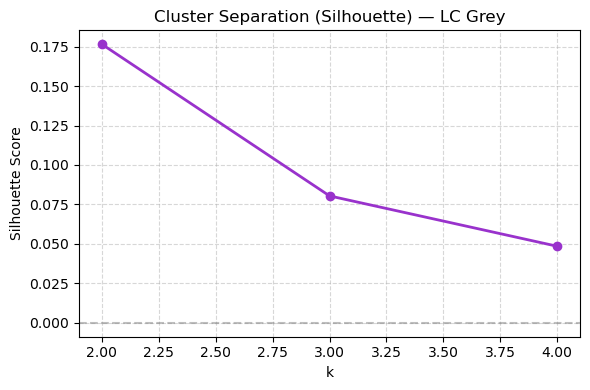

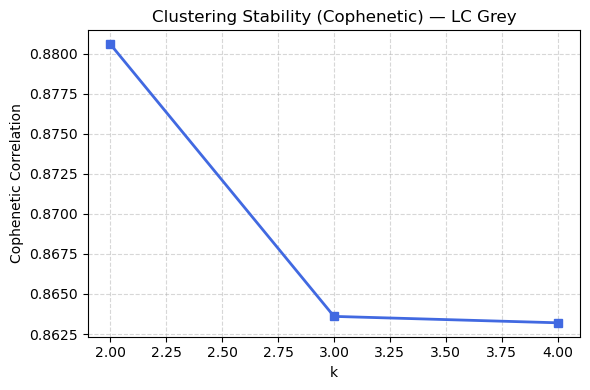

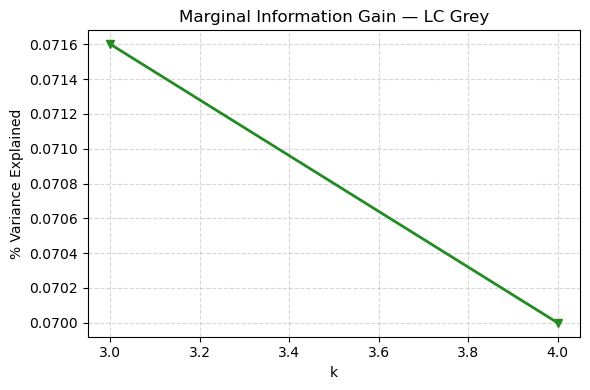

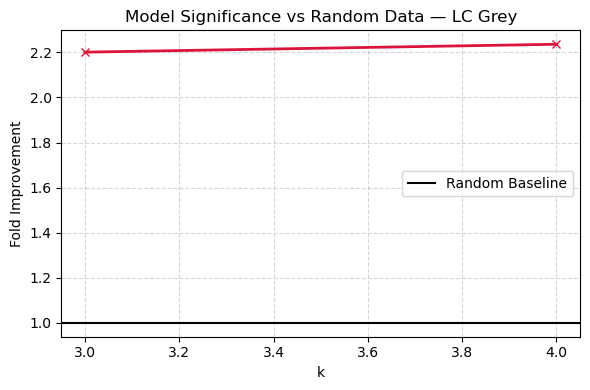

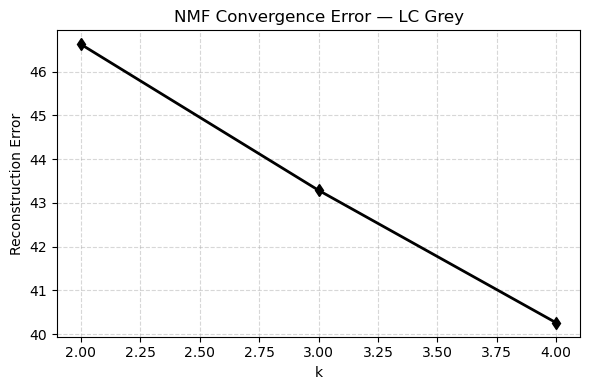

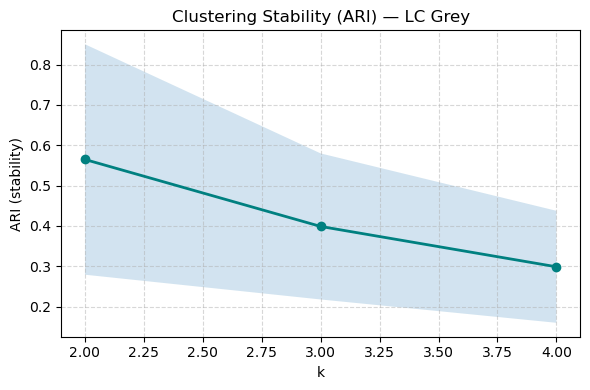

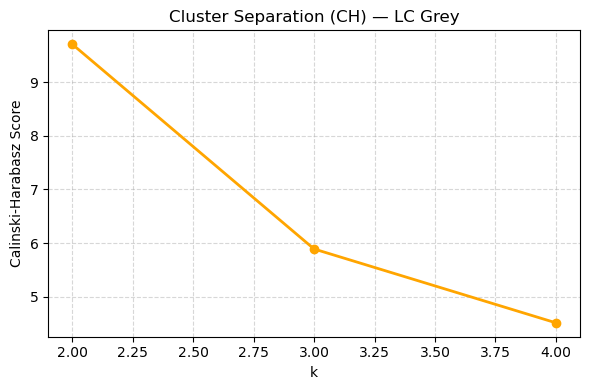

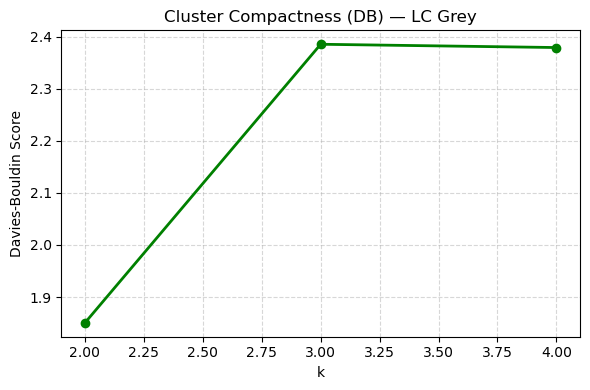

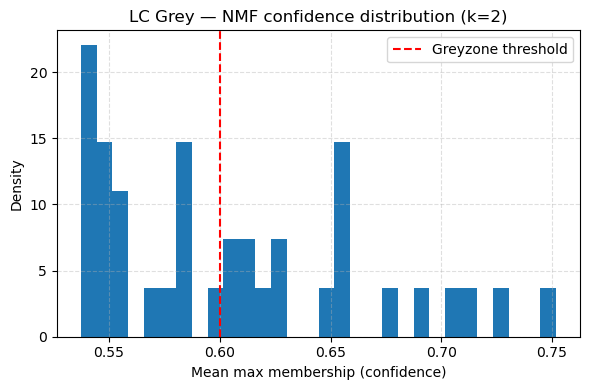

In [75]:
k_range = [2, 3, 4]

results_nmf_LC_grey, labels_nmf_LC_grey = nmf_stability_pipeline(
    LC_grey_df,
    k_range,
    feature_names=proteins_present_LC,
    n_runs=60
)

import matplotlib.pyplot as plt

# Definiamo i dati dai tuoi risultati
ks = results_nmf_LC_grey.index

# 1. SILHOUETTE SCORE
plt.figure(figsize=(6, 4))

plt.plot(
    ks,
    results_nmf_LC_grey["silhouette"],
    marker='o',
    color='darkorchid',
    linewidth=2
)

plt.axhline(0, color='gray', linestyle='--', alpha=0.5)

plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Cluster Separation (Silhouette) — LC Grey")

plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig('Silhouette_Score_LC_Grey')

plt.show()

# 2. COPHENETIC CORRELATION
plt.figure(figsize=(6, 4))

plt.plot(
    ks,
    results_nmf_LC_grey["cophenetic"],
    marker='s',
    color='royalblue',
    linewidth=2
)

plt.xlabel("k")
plt.ylabel("Cophenetic Correlation")
plt.title("Clustering Stability (Cophenetic) — LC Grey")

plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig('Cophenetic_Correlation_LC_Grey')

plt.show()

# 3. % VARIANCE EXPLAINED
plt.figure(figsize=(6, 4))

plt.plot(
    ks,
    results_nmf_LC_grey["perc_variance_explained"],
    marker='v',
    color='forestgreen',
    linewidth=2
)

plt.xlabel("k")
plt.ylabel("% Variance Explained")
plt.title("Marginal Information Gain — LC Grey")

plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig('Marginal_information_gain_LC_Grey')

plt.show()

# 4. FOLD IMPROVEMENT
plt.figure(figsize=(6, 4))

plt.plot(
    ks,
    results_nmf_LC_grey["fold_improvement"],
    marker='x',
    color='crimson',
    linewidth=2
)

plt.axhline(
    1,
    color='black',
    linestyle='-',
    label="Random Baseline"
)

plt.xlabel("k")
plt.ylabel("Fold Improvement")
plt.title("Model Significance vs Random Data — LC Grey")

plt.legend()

plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig('Model_Significance_vs_Random_Data_LC_Grey')

plt.show()

# 5. RECONSTRUCTION ERROR
plt.figure(figsize=(6, 4))

plt.plot(
    ks,
    results_nmf_LC_grey["error_mean"],
    marker='d',
    color='black',
    linewidth=2
)

plt.xlabel("k")
plt.ylabel("Reconstruction Error")
plt.title("NMF Convergence Error — LC Grey")

plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig('NMF_converge_error_LC_Grey')

plt.show()

# 6. ARI STABILITY
plt.figure(figsize=(6, 4))

plt.plot(
    ks,
    results_nmf_LC_grey["ari_mean"],
    marker='o',
    color='teal',
    linewidth=2
)

plt.fill_between(
    ks,
    results_nmf_LC_grey["ari_mean"] - results_nmf_LC_grey["ari_std"],
    results_nmf_LC_grey["ari_mean"] + results_nmf_LC_grey["ari_std"],
    alpha=0.2
)

plt.xlabel("k")
plt.ylabel("ARI (stability)")
plt.title("Clustering Stability (ARI) — LC Grey")

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig('ARI_Stability_LC_Grey')

plt.show()

# 7. CALINSKI-HARABASZ
plt.figure(figsize=(6, 4))

plt.plot(
    ks,
    results_nmf_LC_grey["CH"],
    marker='o',
    color='orange',
    linewidth=2
)

plt.xlabel("k")
plt.ylabel("Calinski-Harabasz Score")
plt.title("Cluster Separation (CH) — LC Grey")

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig('CH_Score_LC_Grey')

plt.show()

# 8. DAVIES-BOULDIN
plt.figure(figsize=(6, 4))

plt.plot(
    ks,
    results_nmf_LC_grey["DB"],
    marker='o',
    color='green',
    linewidth=2
)

plt.xlabel("k")
plt.ylabel("Davies-Bouldin Score")
plt.title("Cluster Compactness (DB) — LC Grey")

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig('DB_Score_LC_Grey')

plt.show()

# 9. MEMBERSHIP DISTRIBUTION
k = 2

labels_list, errors, models, W_list = run_nmf_multiple(
    LC_grey_df,
    k,
    n_runs=60
)

plot_global_membership_distribution(
    W_list,
    title="LC Grey — NMF confidence distribution (k=2)",
    dataset_name="LC_Grey",
    output_dir="NMF_confidence_distribution/"
)